**Name:** Abhi Mondal       
**Roll No:**  22MS075

In [2]:
# packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from numba import njit              # used for fast compilation (for install run "pip install numba")

In [23]:
@njit
# function to perform the Moran Process
# input: population size, number of rounds, payoff matrix, initial number of A in the population
# output: frequency array of A 
def simulation_moran(N,m, payoff_matrix, initial_A):
    # initialize the population
    pop = np.ones(N,dtype=np.int32)
    pop[:initial_A] = 0             # A -> 0 and B -> 1
    np.random.shuffle(pop)          # shuffle the population

    # track the count of A
    count_A = initial_A
    freq_A_hist = [np.float64(count_A)/N]

    steps = 0

    # run until fixation (A reaches 0 or N)
    while count_A > 0 and count_A < N:
        # calculation of payoffs via random pair-wise interactions
        fitness = np.ones(N, dtype= np.float64) # as basal fitness is 1

        for i in range(N):
            # pick a random numberf from the population for opponent -> omit self index
            opp_idx = np.random.randint(0,N)
            while opp_idx == i:
                opp_idx = np.random.randint(0,N)
            
            cumulative_payoff = 0.0
            # repeat for m round
            for round in range(m):
                cumulative_payoff+= payoff_matrix[round,pop[i],pop[opp_idx]]

            fitness[i] += cumulative_payoff
        
        max_f = np.max(fitness)
        parent_idx = -1
        # selection for reproduction
        while parent_idx == -1:
            candidate = np.random.randint(0, N) # Pick a Random member
            
            # compare with normalized fitness for reproduction
            if np.random.random() < (fitness[candidate] / max_f):
                parent_idx = candidate # picked for reproduction

        
        # selection for death
        death_idx = np.random.randint(0, N)
        
        # exchange
        old_trait = pop[death_idx]
        new_trait = pop[parent_idx]
        
        pop[death_idx] = new_trait
        
        # tracking of frequencies
        if old_trait == 0 and new_trait == 1:
            count_A -= 1
        elif old_trait == 1 and new_trait == 0:
            count_A += 1
            
        steps += 1

        # record frequency of A
        if steps % N == 0:
            freq_A_hist.append(count_A / N)
            
    # final frequency add 
    if steps % N != 0:
        freq_A_hist.append(count_A / N)
            
    return freq_A_hist

In [4]:
# parameters
# population size 
N = 1000
# number of rounds
m = 4

In [5]:
# Question 1 
# A=ALLC, B=ALLD
# payoff matrix elements -> define for each round 
a = 4; b = 1; c = 6; d =2
pd_matrix_1 = np.zeros((m, 2, 2), dtype=np.float64)
for r in range(m):
    pd_matrix_1[r] = [
        [a, b], # A vs A, A vs B
        [c, d]  # B vs A, B vs B
    ]
print("Simulating game for ALLC vs ALLD...")
freq_ALLC_Q1 = np.array(simulation_moran(N, m, pd_matrix_1, 500))
freq_ALLD_Q1 = 1 - freq_ALLC_Q1
print("Done!")

Simulating game for ALLC vs ALLD...
Done!


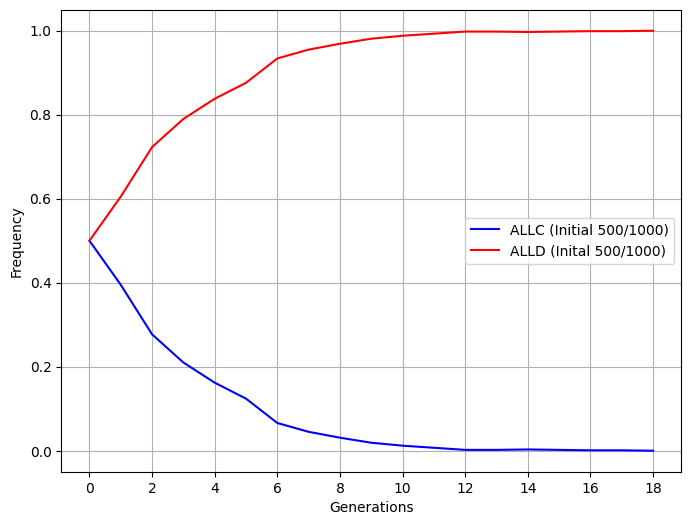

In [7]:
plt.figure(figsize=(8, 6))
plt.plot(freq_ALLC_Q1, label="ALLC (Initial 500/1000)", color='blue')
plt.plot(freq_ALLD_Q1, label="ALLD (Inital 500/1000)", color='red')
plt.xlabel("Generations")
plt.ylabel("Frequency")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend(loc = "best")
plt.grid(True)
plt.show()

In [ ]:
# Question 2
# A=TFT, B=ALLD
pd_matrix_2 = np.zeros((m, 2, 2), dtype=np.float64)

# round 0 when TFT cooperates and ALLD defects
pd_matrix_2[0] = [
    [a, b], # TFT cooperates, ALLD defects -> TFT gets 'b'
    [c, d]  # ALLD defects, TFT cooperates -> ALLD gets 'c'
]

# other than first round TFT retaliates by copying ALLD's previous defect move. 
# it becomes a ALLD vs ALLD game for the remaining rounds.
for r in range(1, m):
    pd_matrix_2[r] = [
        [a, d], # TFT vs ALLD -> both defect -> TFT gets 'd'
        [d, d]  # ALLD vs TFT -> both defect -> ALLD gets 'd'
    ]

print("Simulating game for TFT vs ALLD, initial TFT 250)...")
freq_TFT_Q2 = np.array(simulation_moran(N, m, pd_matrix_2, 250))
freq_ALLD_Q2 = 1 - freq_TFT_Q2
print("Done!")

print("Simulating game for TFT vs ALLD, initial TFT 150)...")
freq_TFT_Q3 = np.array(simulation_moran(N, m, pd_matrix_2, 150))
freq_ALLD_Q3 = 1 - freq_TFT_Q3
print("Done!")

Simulating game for TFT vs ALLD, initial TFT 250)...
Done!
Simulating game for TFT vs ALLD, initial TFT 150)...
Done!


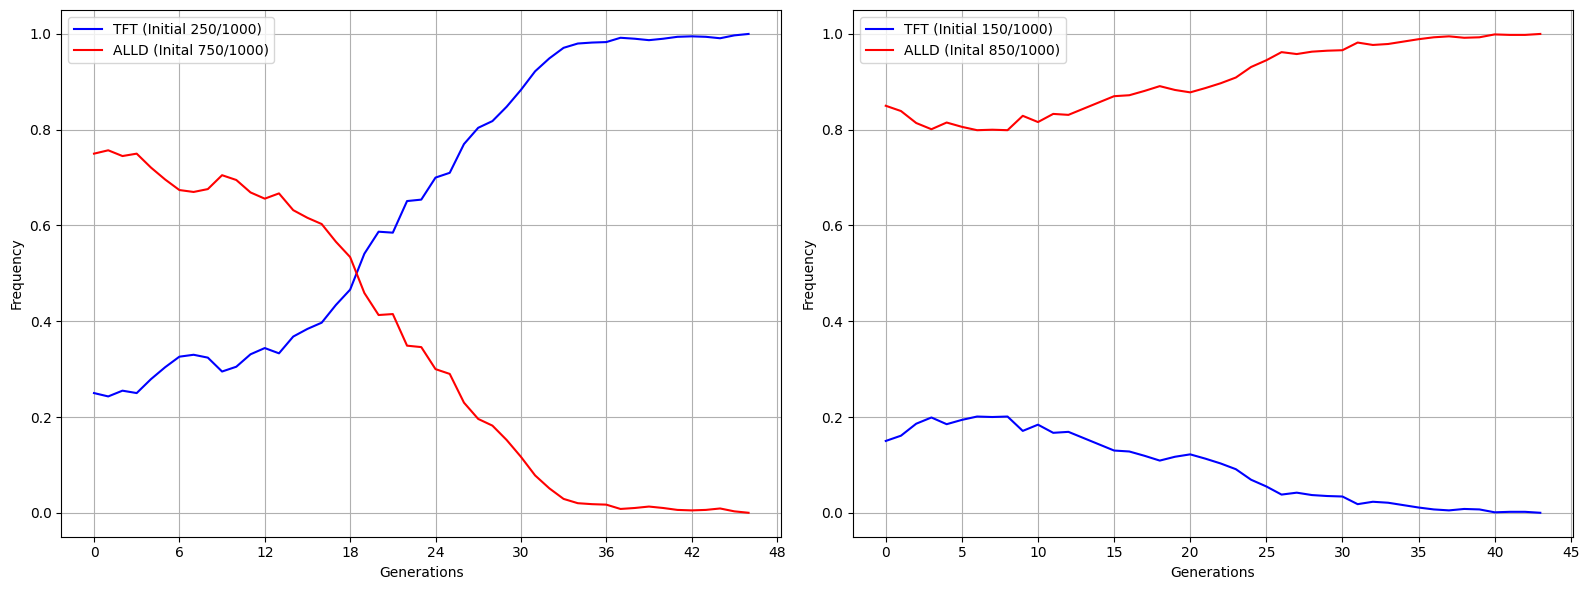

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(freq_TFT_Q2, label="TFT (Initial 250/1000)", color='blue')
axes[0].plot(freq_ALLD_Q2, label="ALLD (Inital 750/1000)", color='red')
axes[0].set_xlabel("Generations")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].legend(loc = "best")
axes[0].grid(True)

axes[1].plot(freq_TFT_Q3, label="TFT (Initial 150/1000)", color='blue')
axes[1].plot(freq_ALLD_Q3, label="ALLD (Inital 850/1000)", color='red')
axes[1].set_xlabel("Generations")
axes[1].set_ylabel("Frequency")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].legend(loc = "best")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Derivation for Unstable Equilibrium frequency of TFT
From the class notes we can find that the unstable equilibrium point for a PD game can be written as following,
$$ 
\begin{bmatrix}
R & S \\
T & P
\end{bmatrix}
$$
where R is Reward (for mutual cooperation), S is Sucker’s payoff, T is Temptation (to defect) and P is Punishment (for mutual defection). Using this notation we can write the unstable equilibrium point is
$$
x^* = \frac{P - S}{(R - T)+(P - S)}
$$
Now for TFT VS ALLD game we can write the payoff matrix incorporating the number of rounds (i.e. m) as following
$$
\begin{array}{c|cc}
 & TFT & ALLD \\
\hline
TFT & ma & b + (m-1)d \\
ALLD & c + (m-1) d & md
\end{array}
$$
Now put that R,S,T,P value in equation for $x^*$ and we have the following value
$$
x^* = \frac{d - b}{m(a-d) + 2d - b - c}
$$
Now put the value of a,b,c,d,m as per the question
$$
x^* = \frac{2-1}{4\times(4-2) + 2\times2 - 1 - 6} = \frac{1}{8 - 3} = \frac{1}{5} = 0.2
$$
In our case, initial population size is 1000, so $x_{TFT} = 1000 \times (1/5) = 200$ is unstable equilibrium point. Bellow this frequency of TFT, the ALLD should dominate and above this point TFT should dominate the population. And this is convenient with the simulation result!


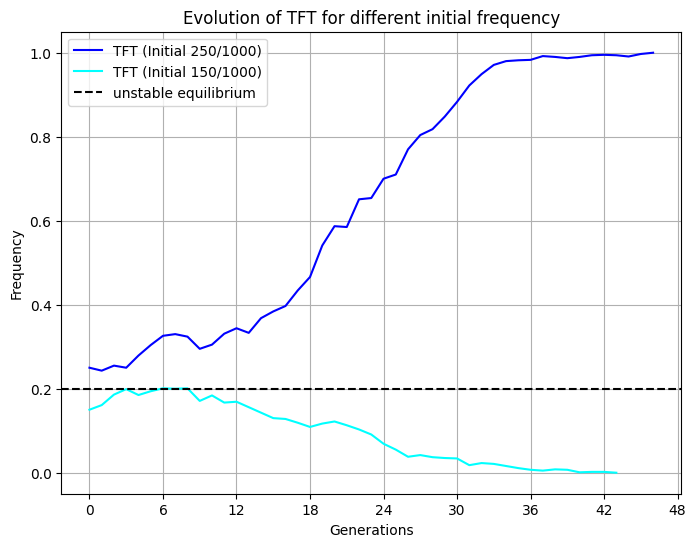

In [22]:
plt.figure(figsize=(8, 6))

plt.plot(freq_TFT_Q2, label="TFT (Initial 250/1000)", color='blue')
# plt.plot(freq_ALLD_Q2, label="ALLD (Inital 750/1000)", color='red')
plt.plot(freq_TFT_Q3, label="TFT (Initial 150/1000)", color='cyan')
# plt.plot(freq_ALLD_Q3, label="ALLD (Inital 850/1000)", color='orange')

plt.axhline(y=0.2, color='black', linestyle='--', label='unstable equilibrium')

plt.xlabel("Generations")
plt.ylabel("Frequency")
plt.title("Evolution of TFT for different initial frequency")
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.legend(loc = "best")
plt.grid(True)
plt.show()